# Estudiante B (Marhia José Granada Restrepo): SDSS & MAST

INNER JOIN relacional entre las tablas de espectroscopía y fotometría. Se utilizan las coordenadas de campo profundo **RA = 135.5 grados**, **Dec = 0.5 grados**, con radio de **0.5 grados**

## 1. Consulta directa

In [19]:
%%bash
mkdir -p datos

# Construct the SQL query
# INNER JOIN links Photometry (u, g) with Spectroscopy (class, redshift)
# fGetNearbyObjEq handles the spatial coordinate matching
ENDPOINT="http://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd="
QUERY="SELECT p.u, p.g, s.class, s.z FROM PhotoObj AS p INNER JOIN SpecObj AS s ON p.objid = s.bestobjid JOIN dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n ON p.objid = n.objid"
# formatoo
URL="${ENDPOINT}${QUERY}"
# Reemplazamos los espacios por %20 para la URL de Sloan
URL_CLEAN=$(echo $URL | sed 's/ /%20/g')

# descargaa
wget -O datos/sdss_datos.csv "$URL_CLEAN"

URL transformed to HTTPS due to an HSTS policy
--2026-10-05 15:35:00--  https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd=SELECT%20p.u,%20p.g,%20s.class,%20s.z%20FROM%20PhotoObj%20AS%20p%20INNER%20JOIN%20SpecObj%20AS%20s%20ON%20p.objid%20=%20s.bestobjid%20JOIN%20dbo.fGetNearbyObjEq(135.5,%200.5,%2030)%20AS%20n%20ON%20p.objid%20=%20n.objid
Resolving skyserver.sdss.org (skyserver.sdss.org)... 128.220.122.33
Connecting to skyserver.sdss.org (skyserver.sdss.org)|128.220.122.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘datos/sdss_datos.csv’

     0K ........                                               36.0M=0s

2026-10-05 15:35:00 (36.0 MB/s) - ‘datos/sdss_datos.csv’ saved [8685]



## 2. Análisis:
En Python, grafica el Corrimiento al Rojo vs Índice de Color ($u -g$
), separando visualmente las Galaxias de los Cuásares.



In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Ingesta y Limpieza
df = pd.read_csv('/content/datos/sdss_datos.csv', skiprows=1, names=['p.u', 'p.g', 's.class', 'redshift'])
df_limpio = df.dropna()

#delete first row
df_limpio = df_limpio.drop(df_limpio.index[0])

# change to float
df_limpio['p.u'] = df_limpio['p.u'].astype(float)
df_limpio['p.g'] = df_limpio['p.g'].astype(float)
df_limpio['redshift'] = df_limpio['redshift'].astype(float)

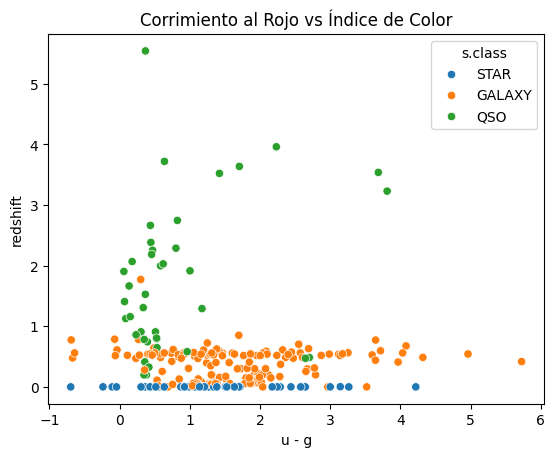

In [21]:
# Graficar corrimiento al rojo vs índice de color separando galaxias

import seaborn as sns
color = df_limpio['p.u'] - df_limpio['p.g']
redshift = df_limpio['redshift']

# graph
sns.scatterplot(x=color, y=redshift, hue=df_limpio['s.class'])
plt.xlabel('u - g')
plt.ylabel('redshift')
plt.title('Corrimiento al Rojo vs Índice de Color')
plt.show()

## 3.Exploración Web:

Utiliza la interfaz web de MAST para buscar si el Telescopio Espacial Hubble (HST) o el James Webb (JWST) han tomado imágenes de alta resolución en las coordenadas exactas de este campo profundo

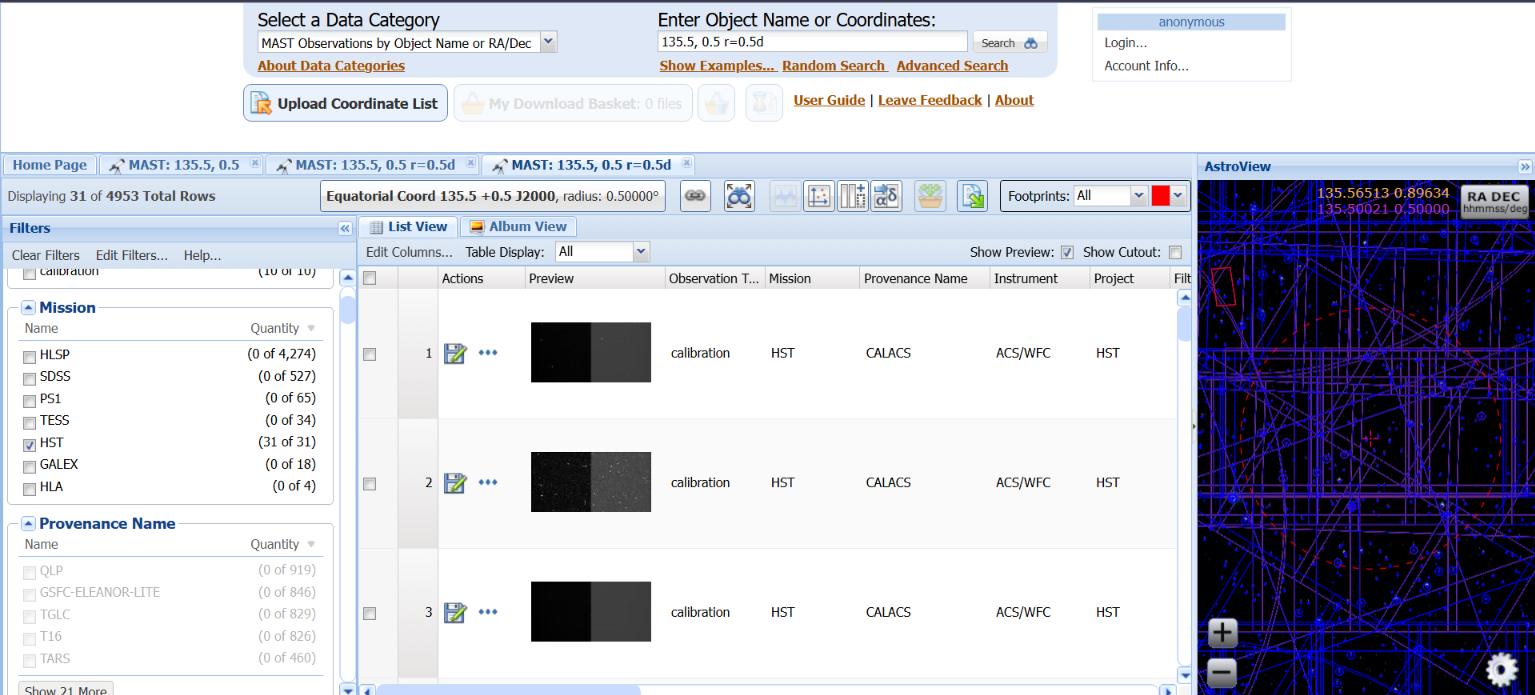